# RiNALMo island matching: can it simplify lncRNA alignment?

The current pipeline: windowed RNA-FM embeddings → MMD matrix → Smith-Waterman.
RiNALMo has context-stable embeddings. Can we just embed whole islands once
and compare directly?

Using 217 real matched island pairs from quick_test (hg38→mm39).

In [1]:
import sys, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

hg38 = TwoBitAccessor(str(REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"))
mm39 = TwoBitAccessor(str(REPO_ROOT / "input_data" / "2bit" / "mm39.2bit"))

print(f"RiNALMo on {device}, genomes loaded")

RiNALMo on mps, genomes loaded


## Load island alignment results + extract sequences

In [2]:
# Load alignment results
results_path = REPO_ROOT / "quick_test" / "island_alignment_results.tsv"
df = pd.read_csv(results_path, sep="\t")
print(f"Matched pairs: {len(df)}")
print(f"Ref island lengths: {df['ref_len'].describe()[['min','50%','max']].to_dict()}")
print(f"Query island lengths: {df['query_len'].describe()[['min','50%','max']].to_dict()}")

# Load strand info from preprocessed reference data
with open(REPO_ROOT / "quick_test" / "preprocessed_reference_data.json") as f:
    ref_data = json.load(f)

# Build strand lookup: (gene_id, island_label) -> strand
ref_strand = {}
for gene_id, gdata in ref_data.items():
    for isl in gdata.get("islands", []):
        label = f"R{isl['island_number']}"
        ref_strand[(gene_id, label)] = isl.get("strand", 1)

# For query islands, use the merged_region strand from clusters
try:
    with open(REPO_ROOT / "quick_test" / "mappings" / "query_regions_clusters.json") as f:
        q_clusters = json.load(f)
    # Build a rough strand lookup from merged transcripts
    q_strand_lookup = {}
    for _, cluster in q_clusters.items():
        strand = cluster["merged_region"].get("strand", 1)
        chrom = cluster["merged_region"]["chrom"]
        for mt in cluster.get("merged_transcripts", []):
            q_strand_lookup[(mt["transcript_id"], chrom)] = strand
except:
    q_strand_lookup = {}

print(f"Ref strand entries: {len(ref_strand)}")
print(f"Query strand entries: {len(q_strand_lookup)}")

Matched pairs: 217
Ref island lengths: {'min': 72.0, '50%': 152.0, 'max': 1128.0}
Query island lengths: {'min': 72.0, '50%': 152.0, 'max': 664.0}
Ref strand entries: 614
Query strand entries: 89


In [3]:
# Extract sequences for all pairs
comp_map = {"A": "U", "T": "A", "G": "C", "C": "G", "N": "N"}

def fetch_seq(accessor, chrom, start, end, strand=1):
    seq = str(accessor.fetch(chrom, int(start), int(end))).upper()
    if strand == -1:
        seq = "".join(comp_map.get(b, "N") for b in reversed(seq))
    else:
        seq = seq.replace("T", "U")
    return seq

pairs = []
skipped = 0
for _, row in df.iterrows():
    # Skip if either island > 1000 nt (RiNALMo training limit)
    if row["ref_len"] > 1000 or row["query_len"] > 1000:
        skipped += 1
        continue

    # Get strands
    r_strand = ref_strand.get((row["gene_id"], row["ref_island"]), 1)
    q_strand = q_strand_lookup.get((row["gene_id"], row["query_chrom"]), 1)

    try:
        ref_seq = fetch_seq(hg38, row["ref_chrom"], row["ref_start"], row["ref_end"], r_strand)
        q_seq = fetch_seq(mm39, row["query_chrom"], row["query_start"], row["query_end"], q_strand)
    except:
        skipped += 1
        continue

    if "N" in ref_seq or "N" in q_seq or len(ref_seq) < 20 or len(q_seq) < 20:
        skipped += 1
        continue

    pairs.append({
        "gene_id": row["gene_id"],
        "ref_island": row["ref_island"], "query_island": row["query_island"],
        "ref_seq": ref_seq, "q_seq": q_seq,
        "ref_len": len(ref_seq), "q_len": len(q_seq),
        "pipeline_mmd": row["diag_mmd"],
        "chain_ref_from": row["chain1_ref_from"], "chain_ref_to": row["chain1_ref_to"],
        "chain_q_from": row["chain1_q_from"], "chain_q_to": row["chain1_q_to"],
        "chain_len_ref": row["chain1_ref_to"] - row["chain1_ref_from"],
        "chain_len_q": row["chain1_q_to"] - row["chain1_q_from"],
    })

print(f"Extracted {len(pairs)} pairs (skipped {skipped})")
pairs_df = pd.DataFrame(pairs)
print(f"Ref lengths: {pairs_df['ref_len'].min()}-{pairs_df['ref_len'].max()} nt")
print(f"Query lengths: {pairs_df['q_len'].min()}-{pairs_df['q_len'].max()} nt")
print(f"Chain lengths (ref): {pairs_df['chain_len_ref'].min()}-{pairs_df['chain_len_ref'].max()} nt")

Extracted 216 pairs (skipped 1)
Ref lengths: 72-856 nt
Query lengths: 72-664 nt
Chain lengths (ref): 72-536 nt


## Whole-island MMD + sub-region findability

For each pair:
1. **Whole-island MMD**: embed ref + query islands fully, compute MMD
2. **Sub-region findability**: slide a chain-length window through query embedding, find MMD minimum vs the matched ref sub-region
3. **Slice vs re-embed**: compare MMD from slicing the whole-island embedding vs re-embedding the sub-region standalone

In [4]:
exp_rows = []

for idx, p in enumerate(pairs):
    ref_emb = emb(p["ref_seq"])
    q_emb = emb(p["q_seq"])

    # 1. Whole-island MMD
    whole_mmd = sn._compute_mmd(ref_emb, q_emb)

    # 2. Sub-region findability
    # Extract the ref sub-region that the pipeline matched
    cr_from, cr_to = int(p["chain_ref_from"]), int(p["chain_ref_to"])
    cq_from, cq_to = int(p["chain_q_from"]), int(p["chain_q_to"])
    chain_len_ref = cr_to - cr_from
    chain_len_q = cq_to - cq_from

    # Slide the ref chain-region through the query embedding
    ref_chain_emb = ref_emb[cr_from:cr_to]  # slice from whole ref embedding
    n_windows = len(q_emb) - chain_len_ref + 1
    found_pos = cq_from  # default
    best_slide_mmd = float("inf")
    slide_mmd_at_true = float("nan")
    if n_windows > 0 and chain_len_ref > 0:
        slide_mmds = np.array([sn._compute_mmd(ref_chain_emb, q_emb[i:i+chain_len_ref])
                               for i in range(n_windows)])
        found_pos = int(np.argmin(slide_mmds))
        best_slide_mmd = slide_mmds[found_pos]
        if cq_from < n_windows:
            slide_mmd_at_true = slide_mmds[cq_from]

    offset = found_pos - cq_from

    # 3. Slice vs re-embed at the matched sub-region
    slice_mmd = sn._compute_mmd(ref_chain_emb, q_emb[cq_from:cq_to]) if cq_to <= len(q_emb) else float("nan")
    reemb_ref = emb(p["ref_seq"][cr_from:cr_to]) if cr_to <= len(p["ref_seq"]) else ref_chain_emb
    reemb_q = emb(p["q_seq"][cq_from:cq_to]) if cq_to <= len(p["q_seq"]) else q_emb[cq_from:cq_to]
    reemb_mmd = sn._compute_mmd(reemb_ref, reemb_q)

    exp_rows.append({
        **{k: p[k] for k in ["gene_id", "ref_len", "q_len", "pipeline_mmd",
                              "chain_len_ref", "chain_len_q"]},
        "whole_mmd": whole_mmd,
        "slide_best_mmd": best_slide_mmd,
        "slide_offset": offset,
        "slice_mmd": slice_mmd,
        "reemb_mmd": reemb_mmd,
    })
    if (idx + 1) % 25 == 0:
        print(f"  {idx+1}/{len(pairs)}")

exp_df = pd.DataFrame(exp_rows)
print(f"\nProcessed {len(exp_df)} pairs")

  25/216
  50/216
  75/216
  100/216
  125/216
  150/216
  175/216
  200/216

Processed 216 pairs


In [5]:
# Results overview
n = len(exp_df)
print("=== Whole-island MMD ===")
print(f"  Pipeline (RNA-FM windowed): mean={exp_df['pipeline_mmd'].mean():.4f}, median={exp_df['pipeline_mmd'].median():.4f}")
print(f"  RiNALMo (whole island):     mean={exp_df['whole_mmd'].mean():.4f}, median={exp_df['whole_mmd'].median():.4f}")
rho, pval = spearmanr(exp_df["pipeline_mmd"], exp_df["whole_mmd"])
print(f"  Spearman correlation: rho={rho:.3f}, p={pval:.1e}")

print(f"\n=== Sub-region findability ===")
n_ok5 = (exp_df["slide_offset"].abs() <= 5).sum()
n_ok10 = (exp_df["slide_offset"].abs() <= 10).sum()
print(f"  Within 5 nt:  {n_ok5}/{n} ({n_ok5/n:.0%})")
print(f"  Within 10 nt: {n_ok10}/{n} ({n_ok10/n:.0%})")
print(f"  Median |offset|: {exp_df['slide_offset'].abs().median():.0f} nt")

print(f"\n=== Slice vs re-embed (at true chain position) ===")
print(f"  Slice from whole:  mean MMD={exp_df['slice_mmd'].mean():.4f}")
print(f"  Re-embed standalone: mean MMD={exp_df['reemb_mmd'].mean():.4f}")
print(f"  Ratio (slice/reemb): {exp_df['slice_mmd'].mean() / exp_df['reemb_mmd'].mean():.2f}x" if exp_df['reemb_mmd'].mean() > 0 else "")

=== Whole-island MMD ===
  Pipeline (RNA-FM windowed): mean=0.0717, median=0.0712
  RiNALMo (whole island):     mean=0.0659, median=0.0593
  Spearman correlation: rho=0.230, p=6.6e-04

=== Sub-region findability ===
  Within 5 nt:  124/216 (57%)
  Within 10 nt: 137/216 (63%)
  Median |offset|: 3 nt

=== Slice vs re-embed (at true chain position) ===
  Slice from whole:  mean MMD=0.0607
  Re-embed standalone: mean MMD=0.0509
  Ratio (slice/reemb): 1.19x


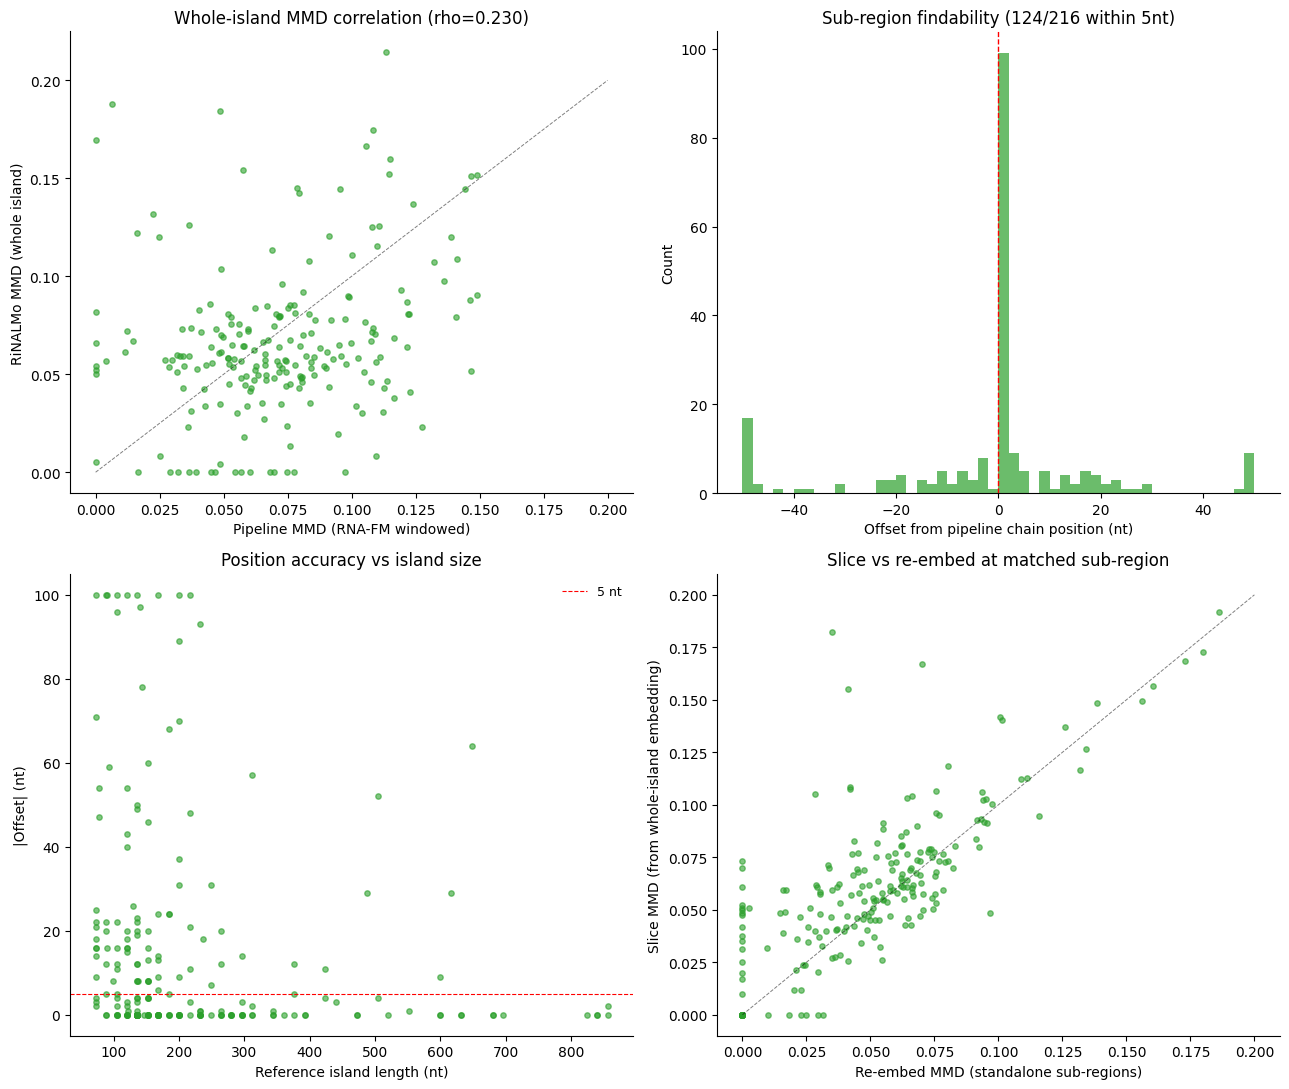

In [6]:
# Plots
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# 1. Pipeline MMD vs RiNALMo whole-island MMD
ax = axes[0][0]
ax.scatter(exp_df["pipeline_mmd"], exp_df["whole_mmd"], s=15, alpha=0.6, c="#2ca02c")
ax.plot([0, 0.2], [0, 0.2], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("Pipeline MMD (RNA-FM windowed)")
ax.set_ylabel("RiNALMo MMD (whole island)")
ax.set_title(f"Whole-island MMD correlation (rho={rho:.3f})")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# 2. Offset distribution
ax = axes[0][1]
ax.hist(exp_df["slide_offset"].clip(-50, 50), bins=50, color="#2ca02c", alpha=0.7)
ax.axvline(0, color="red", lw=1, ls="--")
ax.set_xlabel("Offset from pipeline chain position (nt)")
ax.set_ylabel("Count")
ax.set_title(f"Sub-region findability ({n_ok5}/{n} within 5nt)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# 3. |Offset| vs island length
ax = axes[1][0]
ax.scatter(exp_df["ref_len"], exp_df["slide_offset"].abs().clip(0, 100), s=15, alpha=0.6, c="#2ca02c")
ax.axhline(5, color="red", ls="--", lw=0.8, label="5 nt")
ax.set_xlabel("Reference island length (nt)")
ax.set_ylabel("|Offset| (nt)")
ax.set_title("Position accuracy vs island size")
ax.legend(fontsize=9, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# 4. Slice vs re-embed MMD
ax = axes[1][1]
ax.scatter(exp_df["reemb_mmd"], exp_df["slice_mmd"], s=15, alpha=0.6, c="#2ca02c")
ax.plot([0, 0.2], [0, 0.2], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("Re-embed MMD (standalone sub-regions)")
ax.set_ylabel("Slice MMD (from whole-island embedding)")
ax.set_title("Slice vs re-embed at matched sub-region")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## What does MMD actually mean for RiNALMo?

Compare real matches (pipeline-validated) vs cross-gene non-matches.
This tells us what threshold to use instead of RNA-FM's 0.15.

In [8]:
# Generate negative pairs: ref island from gene X, query island from gene Y
import random as rng_mod
from sklearn.metrics import roc_auc_score, roc_curve
rng_mod.seed(42)

neg_mmds = []
shuffled_idx = list(range(len(pairs)))
rng_mod.shuffle(shuffled_idx)
n_neg = min(100, len(pairs))

for i in range(n_neg):
    a = pairs[shuffled_idx[i]]
    b = pairs[shuffled_idx[(i + n_neg//2) % len(pairs)]]
    if a["gene_id"] == b["gene_id"]:
        continue
    ref_e = emb(a["ref_seq"])
    q_e = emb(b["q_seq"])
    neg_mmds.append(sn._compute_mmd(ref_e, q_e))
    if len(neg_mmds) % 25 == 0:
        print(f"  {len(neg_mmds)} negative pairs done")

neg_mmds = np.array(neg_mmds)
pos_mmds = exp_df["whole_mmd"].values

print(f"\nPositive (real matches): n={len(pos_mmds)}, median={np.median(pos_mmds):.4f}")
print(f"Negative (cross-gene):   n={len(neg_mmds)}, median={np.median(neg_mmds):.4f}")

  25 negative pairs done
  50 negative pairs done
  75 negative pairs done

Positive (real matches): n=216, median=0.0593
Negative (cross-gene):   n=94, median=0.0712


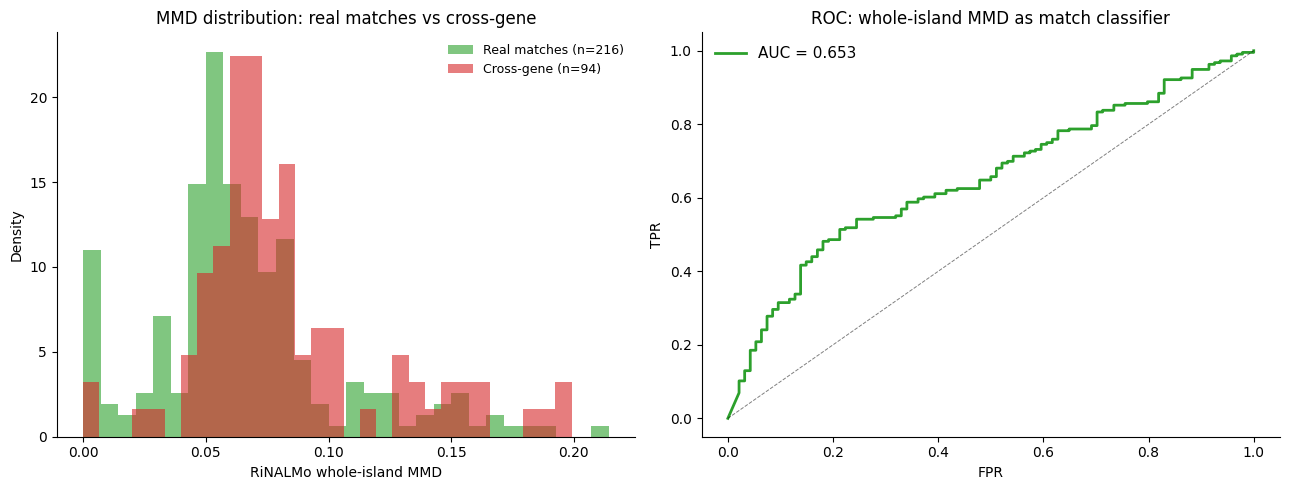


AUC = 0.6528

At various thresholds:
  MMD < 0.05: TPR=0.30, FPR=0.09
  MMD < 0.08: TPR=0.75, FPR=0.61
  MMD < 0.10: TPR=0.86, FPR=0.79
  MMD < 0.12: TPR=0.89, FPR=0.83
  MMD < 0.15: TPR=0.95, FPR=0.90
  MMD < 0.20: TPR=1.00, FPR=1.00


In [9]:
# ROC + histogram
all_mmds = np.concatenate([pos_mmds, neg_mmds])
all_labels = np.array([1]*len(pos_mmds) + [0]*len(neg_mmds))
auc = roc_auc_score(all_labels, -all_mmds)  # lower MMD = more similar = positive

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(pos_mmds, bins=30, alpha=0.6, color="#2ca02c", label=f"Real matches (n={len(pos_mmds)})", density=True)
ax.hist(neg_mmds, bins=30, alpha=0.6, color="#d62728", label=f"Cross-gene (n={len(neg_mmds)})", density=True)
ax.set_xlabel("RiNALMo whole-island MMD")
ax.set_ylabel("Density")
ax.set_title("MMD distribution: real matches vs cross-gene")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax = axes[1]
fpr, tpr, thresholds = roc_curve(all_labels, -all_mmds)
ax.plot(fpr, tpr, color="#2ca02c", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1],"k--",lw=0.7,alpha=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC: whole-island MMD as match classifier")
ax.legend(frameon=False, fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nAUC = {auc:.4f}")
print(f"\nAt various thresholds:")
for t in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    tp = (pos_mmds < t).mean()
    fp = (neg_mmds < t).mean()
    print(f"  MMD < {t:.2f}: TPR={tp:.2f}, FPR={fp:.2f}")

## Summary

In [7]:
print("=" * 70)
print("CAN RINALMO SIMPLIFY ISLAND MATCHING?")
print("=" * 70)

print(f"\nDataset: {len(exp_df)} matched island pairs (hg38 vs mm39)")
print(f"Island sizes: ref {exp_df['ref_len'].min()}-{exp_df['ref_len'].max()} nt, "
      f"query {exp_df['q_len'].min()}-{exp_df['q_len'].max()} nt")

print(f"\n--- Q1: Does whole-island MMD correlate with pipeline? ---")
print(f"  Spearman rho = {rho:.3f} (p = {pval:.1e})")
below_thresh = (exp_df["whole_mmd"] < 0.15).sum()
print(f"  {below_thresh}/{n} ({below_thresh/n:.0%}) have whole-island MMD < 0.15")

print(f"\n--- Q2: Can you find the matched sub-region by slicing? ---")
print(f"  Within 5 nt:  {n_ok5}/{n} ({n_ok5/n:.0%})")
print(f"  Within 10 nt: {n_ok10}/{n} ({n_ok10/n:.0%})")

print(f"\n--- Q3: Does slicing preserve embedding quality? ---")
print(f"  Slice MMD:   {exp_df['slice_mmd'].mean():.4f} (mean)")
print(f"  Re-embed MMD: {exp_df['reemb_mmd'].mean():.4f} (mean)")
close = (exp_df["slice_mmd"] - exp_df["reemb_mmd"]).abs()
print(f"  Mean |difference|: {close.mean():.4f}")
print(f"  Slice ≈ re-embed (diff < 0.02): {(close < 0.02).sum()}/{n} ({(close < 0.02).sum()/n:.0%})")

CAN RINALMO SIMPLIFY ISLAND MATCHING?

Dataset: 216 matched island pairs (hg38 vs mm39)
Island sizes: ref 72-856 nt, query 72-664 nt

--- Q1: Does whole-island MMD correlate with pipeline? ---
  Spearman rho = 0.230 (p = 6.6e-04)
  205/216 (95%) have whole-island MMD < 0.15

--- Q2: Can you find the matched sub-region by slicing? ---
  Within 5 nt:  124/216 (57%)
  Within 10 nt: 137/216 (63%)

--- Q3: Does slicing preserve embedding quality? ---
  Slice MMD:   0.0607 (mean)
  Re-embed MMD: 0.0509 (mean)
  Mean |difference|: 0.0172
  Slice ≈ re-embed (diff < 0.02): 144/216 (67%)


## Redo everything with PCA k=16

The calibration notebook showed PCA stretches the useful MMD range and improves
within/between-class separation (3.7x vs 2.3x raw). Suggested threshold: ~0.12.

In [10]:
from sklearn.decomposition import PCA

# Fit PCA on all island token embeddings (ncRNA pool)
print("Collecting token embeddings for PCA fitting...")
all_tokens = []
for p in pairs:
    all_tokens.append(emb(p["ref_seq"]))
    all_tokens.append(emb(p["q_seq"]))
    if len(all_tokens) % 100 == 0:
        print(f"  {len(all_tokens)} sequences embedded")

X_pool = np.vstack(all_tokens).astype(np.float32)
print(f"PCA pool: {X_pool.shape}")

pca16 = PCA(n_components=16).fit(X_pool)
print(f"PCA k=16: {pca16.explained_variance_ratio_.sum():.1%} variance")

def emb_pca(seq):
    return pca16.transform(emb(seq))

  100 sequences embedded
  200 sequences embedded
  300 sequences embedded
  400 sequences embedded
PCA pool: (87698, 1280)
PCA k=16: 52.6% variance


In [11]:
# Redo: whole-island MMD + findability + slice vs reemb in PCA space
pca_rows = []

for idx, p in enumerate(pairs):
    ref_e = emb_pca(p["ref_seq"])
    q_e = emb_pca(p["q_seq"])

    whole_mmd = sn._compute_mmd(ref_e, q_e)

    cr_from, cr_to = int(p["chain_ref_from"]), int(p["chain_ref_to"])
    cq_from, cq_to = int(p["chain_q_from"]), int(p["chain_q_to"])
    chain_len_ref = cr_to - cr_from

    ref_chain_e = ref_e[cr_from:cr_to]
    n_windows = len(q_e) - chain_len_ref + 1
    found_pos = cq_from
    best_slide_mmd = float("inf")
    if n_windows > 0 and chain_len_ref > 0:
        slide_mmds = np.array([sn._compute_mmd(ref_chain_e, q_e[i:i+chain_len_ref])
                               for i in range(n_windows)])
        found_pos = int(np.argmin(slide_mmds))
        best_slide_mmd = slide_mmds[found_pos]

    offset = found_pos - cq_from

    slice_mmd = sn._compute_mmd(ref_chain_e, q_e[cq_from:cq_to]) if cq_to <= len(q_e) else float("nan")
    reemb_mmd = sn._compute_mmd(emb_pca(p["ref_seq"][cr_from:cr_to]),
                                 emb_pca(p["q_seq"][cq_from:cq_to])) if cq_to <= len(p["q_seq"]) and cr_to <= len(p["ref_seq"]) else float("nan")

    pca_rows.append({
        "gene_id": p["gene_id"], "ref_len": p["ref_len"], "q_len": p["q_len"],
        "pipeline_mmd": p["pipeline_mmd"],
        "chain_len_ref": p["chain_len_ref"],
        "whole_mmd": whole_mmd,
        "slide_best_mmd": best_slide_mmd,
        "slide_offset": offset,
        "slice_mmd": slice_mmd,
        "reemb_mmd": reemb_mmd,
    })
    if (idx + 1) % 50 == 0:
        print(f"  {idx+1}/{len(pairs)}")

pca_df = pd.DataFrame(pca_rows)
print(f"\nProcessed {len(pca_df)} pairs in PCA space")

  50/216
  100/216
  150/216
  200/216

Processed 216 pairs in PCA space


In [12]:
# Cross-gene negatives in PCA space
import random as rng_mod
from sklearn.metrics import roc_auc_score, roc_curve
rng_mod.seed(42)

pca_neg_mmds = []
shuffled_idx = list(range(len(pairs)))
rng_mod.shuffle(shuffled_idx)
n_neg = min(100, len(pairs))

for i in range(n_neg):
    a = pairs[shuffled_idx[i]]
    b = pairs[shuffled_idx[(i + n_neg//2) % len(pairs)]]
    if a["gene_id"] == b["gene_id"]:
        continue
    pca_neg_mmds.append(sn._compute_mmd(emb_pca(a["ref_seq"]), emb_pca(b["q_seq"])))
    if len(pca_neg_mmds) % 25 == 0:
        print(f"  {len(pca_neg_mmds)} negative pairs")

pca_neg_mmds = np.array(pca_neg_mmds)
print(f"\nNegative pairs: {len(pca_neg_mmds)}")

  25 negative pairs
  50 negative pairs
  75 negative pairs

Negative pairs: 94


In [13]:
# Side-by-side: Raw vs PCA k=16
n = len(pca_df)
n_ok5 = (pca_df["slide_offset"].abs() <= 5).sum()
n_ok10 = (pca_df["slide_offset"].abs() <= 10).sum()
rho_pca, _ = spearmanr(pca_df["pipeline_mmd"], pca_df["whole_mmd"])

pos_pca = pca_df["whole_mmd"].values
all_mmds_pca = np.concatenate([pos_pca, pca_neg_mmds])
all_labels_pca = np.array([1]*len(pos_pca) + [0]*len(pca_neg_mmds))
auc_pca = roc_auc_score(all_labels_pca, -all_mmds_pca)

# Raw results for comparison
n_ok5_raw = (exp_df["slide_offset"].abs() <= 5).sum()
n_ok10_raw = (exp_df["slide_offset"].abs() <= 10).sum()
rho_raw, _ = spearmanr(exp_df["pipeline_mmd"], exp_df["whole_mmd"])
auc_raw = roc_auc_score(all_labels, -all_mmds)  # from earlier

print(f"{'Metric':>30s}  {'Raw 1280':>10s}  {'PCA k=16':>10s}")
print("-" * 55)
print(f"{'Whole-island MMD (median)':>30s}  {exp_df['whole_mmd'].median():>10.4f}  {pca_df['whole_mmd'].median():>10.4f}")
print(f"{'Corr with pipeline (rho)':>30s}  {rho_raw:>10.3f}  {rho_pca:>10.3f}")
print(f"{'Match/non-match AUC':>30s}  {auc_raw:>10.4f}  {auc_pca:>10.4f}")
print(f"{'Findability within 5 nt':>30s}  {n_ok5_raw:>7d}/{n}  {n_ok5:>7d}/{n}")
print(f"{'Findability within 10 nt':>30s}  {n_ok10_raw:>7d}/{n}  {n_ok10:>7d}/{n}")
print(f"{'Median |offset|':>30s}  {exp_df['slide_offset'].abs().median():>10.0f}  {pca_df['slide_offset'].abs().median():>10.0f}")
print(f"{'Slice MMD (mean)':>30s}  {exp_df['slice_mmd'].mean():>10.4f}  {pca_df['slice_mmd'].mean():>10.4f}")
print(f"{'Re-embed MMD (mean)':>30s}  {exp_df['reemb_mmd'].mean():>10.4f}  {pca_df['reemb_mmd'].mean():>10.4f}")

                        Metric    Raw 1280    PCA k=16
-------------------------------------------------------
     Whole-island MMD (median)      0.0593      0.0766
      Corr with pipeline (rho)       0.230       0.270
           Match/non-match AUC      0.6528      0.6846
       Findability within 5 nt      124/216      120/216
      Findability within 10 nt      137/216      141/216
               Median |offset|           3           3
              Slice MMD (mean)      0.0607      0.0663
           Re-embed MMD (mean)      0.0509      0.0481


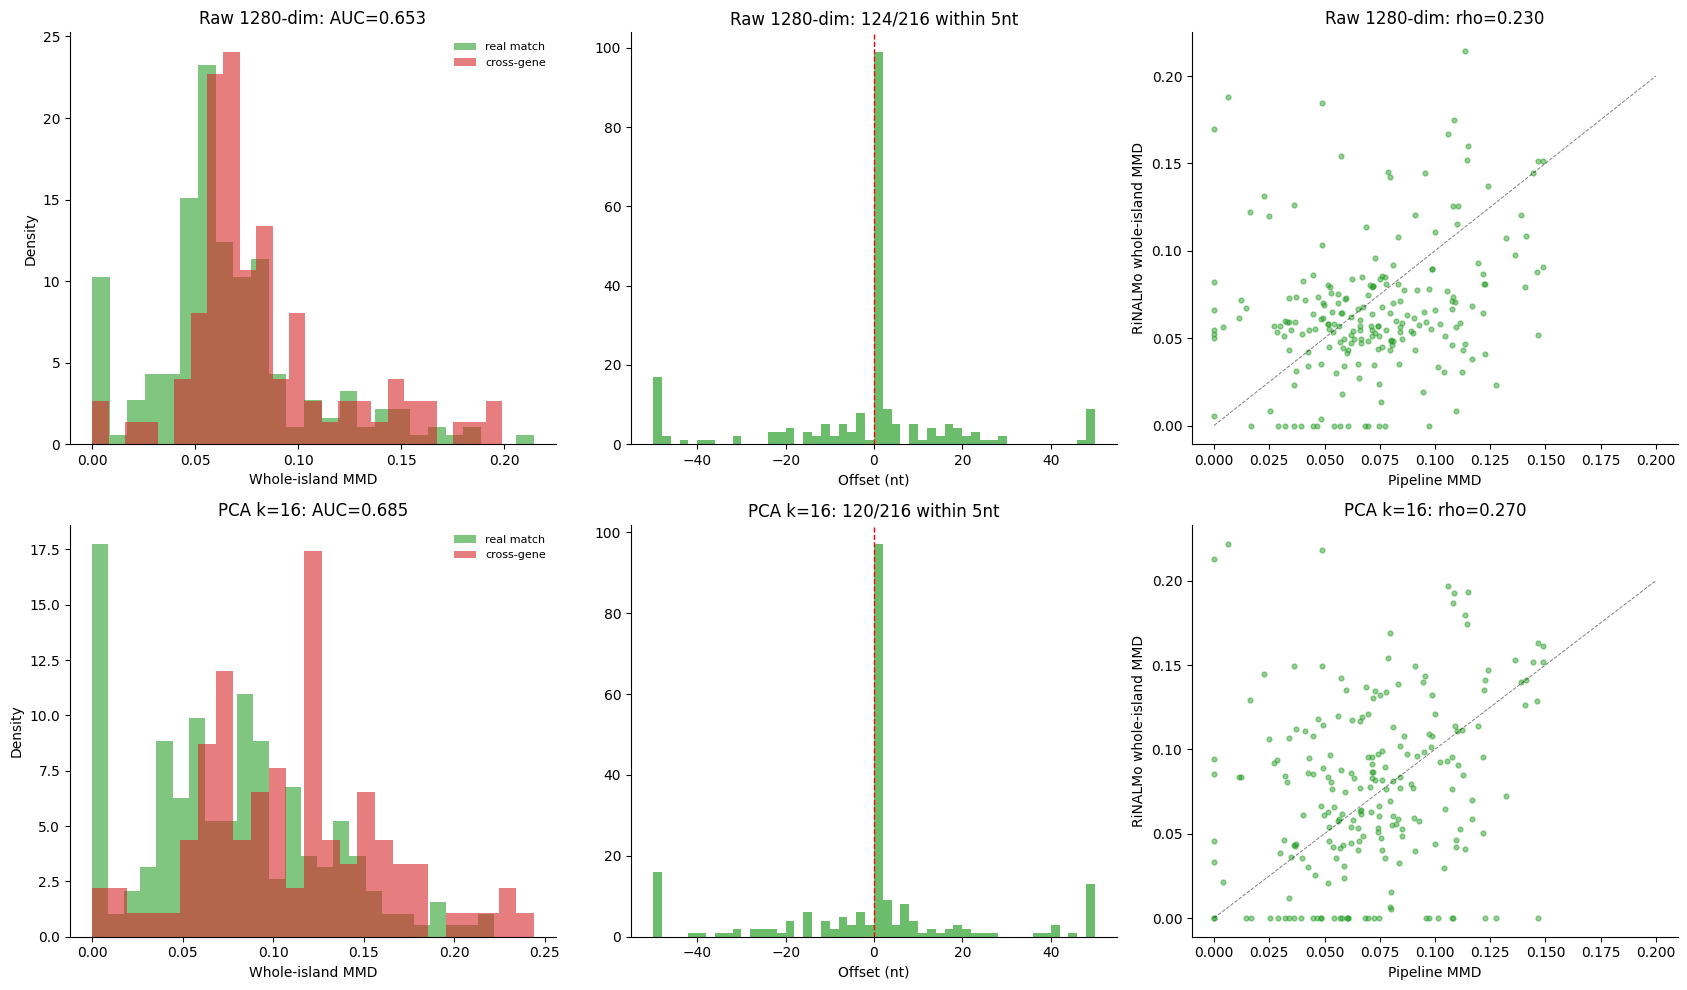

In [14]:
# Plots: Raw vs PCA comparison
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row_idx, (title, edf, pos_m, neg_m, auc_v, rho_v) in enumerate([
    ("Raw 1280-dim", exp_df, pos_mmds, neg_mmds, auc_raw, rho_raw),
    ("PCA k=16", pca_df, pos_pca, pca_neg_mmds, auc_pca, rho_pca),
]):
    # Col 1: match vs non-match histogram
    ax = axes[row_idx][0]
    ax.hist(pos_m, bins=25, alpha=0.6, color="#2ca02c", label="real match", density=True)
    ax.hist(neg_m, bins=25, alpha=0.6, color="#d62728", label="cross-gene", density=True)
    ax.set_xlabel("Whole-island MMD")
    ax.set_ylabel("Density")
    ax.set_title(f"{title}: AUC={auc_v:.3f}")
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    # Col 2: findability offset histogram
    ax = axes[row_idx][1]
    n5 = (edf["slide_offset"].abs() <= 5).sum()
    ax.hist(edf["slide_offset"].clip(-50, 50), bins=50, color="#2ca02c", alpha=0.7)
    ax.axvline(0, color="red", lw=1, ls="--")
    ax.set_xlabel("Offset (nt)")
    ax.set_title(f"{title}: {n5}/{len(edf)} within 5nt")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    # Col 3: pipeline correlation
    ax = axes[row_idx][2]
    ax.scatter(edf["pipeline_mmd"], edf["whole_mmd"], s=12, alpha=0.5, c="#2ca02c")
    ax.plot([0, 0.2], [0, 0.2], "k--", lw=0.7, alpha=0.5)
    ax.set_xlabel("Pipeline MMD")
    ax.set_ylabel("RiNALMo whole-island MMD")
    ax.set_title(f"{title}: rho={rho_v:.3f}")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Window size experiment: how big can windows be?

Current pipeline: 96 nt windows, stride 4 (96% overlap) — forced by RNA-FM context dependency.
RiNALMo tolerates ±5 nt shifts at MMD=0. So test bigger windows + bigger strides.

For each pair: build an MMD matrix (ref windows × query windows), find the
best-matching diagonal, compare to the pipeline's known chain.

In [15]:
# Window configurations to test
CONFIGS = [
    {"name": "pipeline (96/4)",   "win": 96,  "stride": 4},
    {"name": "medium (128/32)",   "win": 128, "stride": 32},
    {"name": "large (256/64)",    "win": 256, "stride": 64},
    {"name": "xlarge (512/128)",  "win": 512, "stride": 128},
    {"name": "huge (512/256)",    "win": 512, "stride": 256},
]

# Filter pairs where both islands are large enough for biggest window
min_len_for_test = 256  # at least need to fit the large window
test_pairs = [p for p in pairs if p["ref_len"] >= min_len_for_test and p["q_len"] >= min_len_for_test]
print(f"Pairs with both islands >= {min_len_for_test} nt: {len(test_pairs)}/{len(pairs)}")

# Also include medium-sized pairs for smaller window configs
med_pairs = [p for p in pairs if p["ref_len"] >= 128 and p["q_len"] >= 128]
print(f"Pairs with both islands >= 128 nt: {len(med_pairs)}/{len(pairs)}")

Pairs with both islands >= 256 nt: 11/216
Pairs with both islands >= 128 nt: 105/216


In [16]:
# For each config × pair: embed islands once, build MMD matrix from slices,
# find best match, compare to pipeline's chain

def windowed_match(ref_emb_pca, q_emb_pca, win, stride, chain_ref_from, chain_ref_to, chain_q_from, chain_q_to):
    """Build MMD matrix from PCA embeddings, find best diagonal match."""
    ref_len = len(ref_emb_pca)
    q_len = len(q_emb_pca)
    if ref_len < win or q_len < win:
        return None

    # Build windows
    ref_wins = list(range(0, ref_len - win + 1, stride))
    q_wins = list(range(0, q_len - win + 1, stride))
    if not ref_wins or not q_wins:
        return None

    # MMD matrix
    mmd_mat = np.zeros((len(ref_wins), len(q_wins)))
    for i, rs in enumerate(ref_wins):
        for j, qs in enumerate(q_wins):
            mmd_mat[i, j] = sn._compute_mmd(ref_emb_pca[rs:rs+win], q_emb_pca[qs:qs+win])

    # Find best matching cell
    best_i, best_j = np.unravel_index(np.argmin(mmd_mat), mmd_mat.shape)
    best_ref_start = ref_wins[best_i]
    best_q_start = q_wins[best_j]
    best_mmd = mmd_mat[best_i, best_j]

    # How close is this to the pipeline's chain?
    # Chain covers ref[chain_ref_from:chain_ref_to] and q[chain_q_from:chain_q_to]
    # Check if the best window overlaps the chain
    ref_overlap = max(0, min(best_ref_start + win, chain_ref_to) - max(best_ref_start, chain_ref_from))
    q_overlap = max(0, min(best_q_start + win, chain_q_to) - max(best_q_start, chain_q_from))
    chain_len = chain_ref_to - chain_ref_from
    ref_hit = ref_overlap / chain_len if chain_len > 0 else 0
    q_hit = q_overlap / (chain_q_to - chain_q_from) if (chain_q_to - chain_q_from) > 0 else 0

    return {
        "best_mmd": best_mmd,
        "best_ref_start": best_ref_start,
        "best_q_start": best_q_start,
        "ref_overlap_frac": ref_hit,
        "q_overlap_frac": q_hit,
        "n_ref_wins": len(ref_wins),
        "n_q_wins": len(q_wins),
        "n_mmd_cells": len(ref_wins) * len(q_wins),
    }

print("Functions defined")

Functions defined


In [18]:
# Run all configs on med_pairs (>= 128 nt)
# Use PCA embeddings
win_rows = []

# Pre-embed all pairs once (PCA)
print("Pre-embedding...")
pair_embs = []
for i, p in enumerate(med_pairs):
    pair_embs.append((emb_pca(p["ref_seq"]), emb_pca(p["q_seq"])))
    if (i+1) % 25 == 0:
        print(f"  {i+1}/{len(med_pairs)}")
print(f"Embedded {len(pair_embs)} pairs")

for cfg in CONFIGS:
    win, stride = cfg["win"], cfg["stride"]
    hits = 0
    total = 0
    total_cells = 0
    for i, p in enumerate(med_pairs):
        if p["ref_len"] < win or p["q_len"] < win:
            continue
        ref_e, q_e = pair_embs[i]
        result = windowed_match(ref_e, q_e, win, stride,
                                int(p["chain_ref_from"]), int(p["chain_ref_to"]),
                                int(p["chain_q_from"]), int(p["chain_q_to"]))
        if result is None:
            continue
        total += 1
        total_cells += result["n_mmd_cells"]
        hit = result["ref_overlap_frac"] >= 0.5 and result["q_overlap_frac"] >= 0.5
        if hit:
            hits += 1
        win_rows.append({"config": cfg["name"], **result, "hit": hit})

    if total > 0:
        avg_cells = total_cells / total
        print(f"  {cfg['name']:>20s}: {hits}/{total} hits ({hits/total:.0%}), "
              f"avg {avg_cells:.0f} MMD cells/pair")
    else:
        print(f"  {cfg['name']:>20s}: no pairs large enough")

win_df = pd.DataFrame(win_rows)

Pre-embedding...
  25/105
  50/105
  75/105
  100/105
Embedded 105 pairs
       pipeline (96/4): 42/105 hits (40%), avg 1550 MMD cells/pair
       medium (128/32): 70/105 hits (67%), avg 19 MMD cells/pair
        large (256/64): 6/11 hits (55%), avg 8 MMD cells/pair
      xlarge (512/128): no pairs large enough
        huge (512/256): no pairs large enough


In [19]:
# Summary table
print(f"{'Config':>20s}  {'Pairs':>5s}  {'Hit rate':>8s}  {'Avg MMD cells':>14s}  {'Speedup':>8s}")
print("-" * 65)

baseline_cells = None
for cfg_name in [c["name"] for c in CONFIGS]:
    sub = win_df[win_df.config == cfg_name]
    if len(sub) == 0:
        print(f"{cfg_name:>20s}  {'n/a':>5s}  {'n/a':>8s}  {'n/a':>14s}  {'n/a':>8s}")
        continue
    n = len(sub)
    hits = sub["hit"].sum()
    avg_cells = sub["n_mmd_cells"].mean()
    if baseline_cells is None:
        baseline_cells = avg_cells
    speedup = baseline_cells / avg_cells if avg_cells > 0 else float("inf")
    print(f"{cfg_name:>20s}  {n:>5d}  {hits/n:>8.0%}  {avg_cells:>14.0f}  {speedup:>7.0f}x")

              Config  Pairs  Hit rate   Avg MMD cells   Speedup
-----------------------------------------------------------------
     pipeline (96/4)    105       40%            1550        1x
     medium (128/32)    105       67%              19       82x
      large (256/64)     11       55%               8      187x
    xlarge (512/128)    n/a       n/a             n/a       n/a
      huge (512/256)    n/a       n/a             n/a       n/a
